# Recreating a BE02-algorithm potential intensity non-convergence case

This is a **diagnostic / documentation notebook** (not part of the test suite). It documents a known numerical edge case of the Bister & Emanuel (2002) potential intensity algorithm as implemented in `tcpyPI.pi`: for certain **marginal (near-neutral) soundings**, the minimum-pressure solver can sometimes fail to converge. In such cases, `pi()` returns `NaN` with the non-convergence flag `IFL=2`.

To illustarte this, we load `pi.py` directly from source and run two nearly-identical real soundings from adjacent days:

- a **problematic** profile that triggers non-convergence (`IFL=2`, `VMAX=NaN`), and
- a **control** profile (the day before) that converges normally (`IFL=1`).

**Key takeaway (detailed after the results):** this is *not* bad input data and *not* a `tcpyPI` bug. It is an oscillation in the BE02 fixed-point pressure iteration for a near-neutral environment, which `tcpyPI` **correctly flags** (returns `NaN` with `IFL=2`) rather than emitting a spurious value. The original MATLAB `pcmin.m` uses the same iteration and shows the same behavior.

# Setup

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path

# -------------------------------------------------------------------------
# STEP 1: Import the local pi.py (portable; no hardcoded path)
# -------------------------------------------------------------------------
# Locate the repo root (src/ layout) and put src/ at the front of sys.path so the
# local source version of tcpyPI is imported (ahead of any pip-installed copy).
here = Path.cwd().resolve()
repo_root = next((c for c in [here, *here.parents] if (c / "src" / "tcpyPI").is_dir()), None)
if repo_root is None:
    raise RuntimeError("Could not locate repo root (expected src/tcpyPI).")
sys.path.insert(0, str(repo_root / "src"))

from tcpyPI import pi

print(">>> using tcpyPI.pi from:", repo_root / "src" / "tcpyPI" / "pi.py")

# Define Data

### Problematic (unstable) profile

A real sounding (day-of-year 287, 1995) over a **marginal** environment: SST ≈ 25.3 °C with a dry mid-troposphere (700 hPa mixing ratio ≈ 1.2 g/kg). The surface parcel has essentially **zero environmental CAPE**, so the potential intensity sits near its lower limit, the regime where the pressure solver is most fragile. This profile returns `IFL=2` / `VMAX=NaN`.

In [3]:
# -------------------------------------------------------------------------
# STEP 2: Problematic profile test
# -------------------------------------------------------------------------

SSTC = 25.267  # Sea surface temp (°C)
MSL = 1012.9   # Mean sea level pressure (hPa)

profile_problematic = np.array([
    [1000.0, 20.266, 9.65],
    [975.0, 18.11, 9.517],
    [950.0, 15.978, 9.459],
    [925.0, 13.94, 9.205],
    [900.0, 12.576, 7.784],
    [875.0, 11.213, 6.561],
    [850.0, 9.669, 5.952],
    [825.0, 8.084, 5.517],
    [800.0, 6.516, 4.976],
    [775.0, 4.993, 4.332],
    [750.0, 4.374, 3.102],
    [700.0, 4.93, 1.207],
    [650.0, 1.852, 1.521],
    [600.0, -2.047, 1.263],
    [550.0, -6.917, 0.857],
    [500.0, -13.015, 0.556],
    [450.0, -19.698, 0.33],
    [400.0, -26.881, 0.211],
    [350.0, -34.178, 0.104],
    [300.0, -42.822, 0.073],
    [250.0, -51.573, 0.037],
    [225.0, -54.68, 0.027],
    [200.0, -57.207, 0.018],
    [175.0, -58.943, 0.01],
    [150.0, -60.751, 0.005],
    [125.0, -63.255, 0.004],
    [100.0, -63.277, 0.003],
    [70.0, -61.5, 0.003],
    [50.0, -58.453, 0.003],
    [30.0, -53.327, 0.003],
    [20.0, -50.156, 0.003],
    [10.0, -46.602, 0.003],
    [7.0, -42.283, 0.003],
    [5.0, -35.389, 0.003],
    [3.0, -22.349, 0.003],
    [2.0, -14.944, 0.004],
    [1.0, -11.886, 0.004],
])

P = profile_problematic[:, 0]
TC = profile_problematic[:, 1]
R = profile_problematic[:, 2]

pi_options = dict(CKCD=0.9, ascent_flag=0, diss_flag=1, ptop=50, miss_handle=1)

VMAX, PMIN, IFL, TO, OTL = pi(SSTC, MSL, P, TC, R, **pi_options)


### Control (stable) profile

The sounding from the **adjacent day** (day-of-year 286, 1995) at nearly the same SST (25.29 °C). It differs only marginally from the problematic profile, yet the solver converges normally and returns a valid `VMAX` (≈ 69 m/s, `IFL=1`). The contrast shows how close to the convergence boundary the problematic case sits.

In [4]:
# -------------------------------------------------------------------------
# STEP 3: Control (working) profile
# -------------------------------------------------------------------------

SSTC_working = 25.292
MSL_working = 1011.4

profile_working = np.array([
    [1000.0, 21.326, 11.215],
    [975.0, 19.192, 11.011],
    [950.0, 17.315, 10.556],
    [925.0, 15.676, 9.931],
    [900.0, 14.286, 8.639],
    [875.0, 12.957, 7.58],
    [850.0, 11.495, 6.97],
    [825.0, 10.019, 6.439],
    [800.0, 8.575, 5.734],
    [775.0, 6.993, 5.198],
    [750.0, 5.373, 4.752],
    [700.0, 3.13, 3.122],
    [650.0, 0.534, 2.562],
    [600.0, -2.573, 1.442],
    [550.0, -6.616, 0.865],
    [500.0, -12.233, 0.61],
    [450.0, -18.954, 0.42],
    [400.0, -26.098, 0.292],
    [350.0, -33.337, 0.184],
    [300.0, -40.639, 0.112],
    [250.0, -49.373, 0.057],
    [225.0, -52.236, 0.03],
    [200.0, -55.706, 0.017],
    [175.0, -57.323, 0.01],
    [150.0, -60.084, 0.005],
    [125.0, -65.224, 0.004],
    [100.0, -65.651, 0.003],
    [70.0, -63.457, 0.003],
    [50.0, -59.522, 0.003],
    [30.0, -53.504, 0.003],
    [20.0, -49.926, 0.003],
    [10.0, -45.925, 0.003],
    [7.0, -41.476, 0.003],
    [5.0, -34.68, 0.003],
    [3.0, -23.495, 0.003],
    [2.0, -16.575, 0.004],
    [1.0, -12.898, 0.004],
])

TC_work = profile_working[:, 1]
R_work = profile_working[:, 2]

VMAX_work, PMIN_work, IFL_work, TO_work, OTL_work = pi(SSTC_working, MSL_working, P, TC_work, R_work, **pi_options)


# Report Results

In [7]:
# Unstable Profile
print("\n" + "=" * 50)
print("TEST: Problematic/Unstable profile (dayofyear=287, year=1995)")
print(f"Surface: SSTC={SSTC}°C, MSL={MSL} hPa")

print("Result:")
print(f"  VMAX: {VMAX:.3f} m/s")
print(f"  PMIN: {PMIN:.3f} hPa")
print(f"  IFL:  {IFL}")
print(f"  TO:   {TO:.3f} K")
print(f"  OTL:  {OTL:.3f} hPa")

if np.isnan(VMAX):
    print("REPRODUCTION SUCCESSFUL: VMAX is NaN")
else:
    print("UNEXPECTED: VMAX is valid")

# Working/Stable Profile
print("\nCONTROL TEST: Working/Stable profile (dayofyear=286, year=1995)")
print(f"Surface: SSTC={SSTC_working}°C, MSL={MSL_working} hPa")

print("Result:")
print(f"  VMAX: {VMAX_work:.3f} m/s")
print(f"  PMIN: {PMIN_work:.3f} hPa")
print(f"  IFL:  {IFL_work}")
print(f"  TO:   {TO_work:.3f} K")
print(f"  OTL:  {OTL_work:.3f} hPa")

if np.isnan(VMAX_work):
    print("Control test FAILED: VMAX is NaN")
else:
    print("Control test SUCCESS: VMAX is valid")


TEST: Problematic/Unstable profile (dayofyear=287, year=1995)
Surface: SSTC=25.267°C, MSL=1012.9 hPa
Result:
  VMAX: nan m/s
  PMIN: nan hPa
  IFL:  2
  TO:   nan K
  OTL:  nan hPa
REPRODUCTION SUCCESSFUL: VMAX is NaN

CONTROL TEST: Working/Stable profile (dayofyear=286, year=1995)
Surface: SSTC=25.292°C, MSL=1011.4 hPa
Result:
  VMAX: 68.983 m/s
  PMIN: 943.025 hPa
  IFL:  1
  TO:   214.151 K
  OTL:  159.826 hPa
Control test SUCCESS: VMAX is valid


## What the results show

The problematic profile returns **`IFL=2` with `VMAX=NaN`**; the control returns a finite `VMAX` (≈ 69 m/s) with `IFL=1`. `IFL=2` is `tcpyPI`'s **non-convergence** flag. This is distinct from invalid input (`IFL=0`) or missing data (`IFL=3`).

**Mechanism.** `pi()` finds the central pressure by iterating using CAT (the scaled CAPE-difference term) informed by the current iteration of the minimum pressure,

$$P_M \leftarrow \mathrm{MSL}\,*\exp\!\left(\frac{-\mathrm{CAT}(P_M)}{R_d\,\bar T_v}\right),$$

This evolves until successive pressures agree to within 0.5 hPa (a convention chosen to balance between numerical stability and precision). For this sounding the iteration does **not** settle — it falls into an **oscillation between ≈ 961.0 and ≈ 961.7 hPa**:

```
PNEW: 963.4 → 961.5 → 961.0 → 961.7 → 961.0 → 961.7 → …   (indefinitely)
```

The oscillation amplitude (~0.7 hPa) is just **larger than the 0.5 hPa convergence tolerance**, so the stopping criterion is never satisfied; the loop runs to its iteration cap (`NP > 200`) and returns `NaN` with `IFL=2`. (It is *not* a "hypercane" runaway — the pressure never approaches the 400 hPa floor.)

**Why here but not the control?** The problematic environment is near-neutral (environmental CAPE ≈ 0 at SST ≈ 25 °C with a dry mid-level), which places the fixed-point map right at the edge where its stable fixed point turns into the oscillation well. The tiny adjacent-day difference in the control profile is enough to restore convergence.

**Interpretation.** This is an intrinsic property of the BE02 solver: the original MATLAB `pcmin.m` uses the same iteration, tolerance (0.5 hPa), and iteration cap and exhibits the same non-convergence. `tcpyPI` handles it **correctly** — flagging `IFL=2` and returning `NaN` rather than a physically meaningless value. The practical guidance for large-dataset applications is therefore to **filter on the flag** (keep `IFL == 1`) and treat `IFL ∈ {0, 2, 3}` points as missing.

*(A fixed-point under-relaxation/averaging step would damp such oscillations and converge these marginal cases, but that would alter the solver for all profiles and disrupt the agreement between the Python and MATLAB solvers — it is deliberately out of scope here; this notebook only documents the behavior.)*

# Visualize the profiles

The two soundings are plotted together — problematic in **red**, control in **blue**, with each surface The non-convergence is a property of the *solver operating near a near-neutral state*, not of an obviously pathological profile. A small difference in an already-marginal environment is all it takes to flip the pressure iteration from a convergent fixed point to a persistent oscillation which never converges.

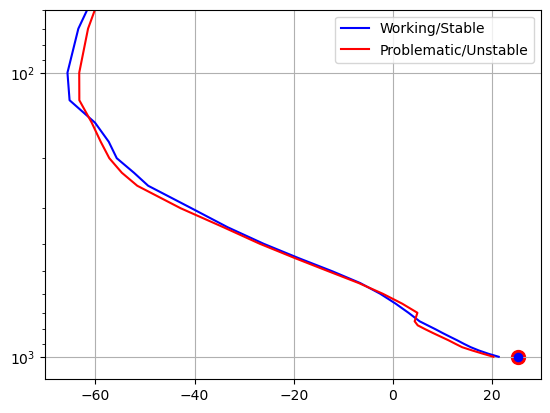

In [8]:
plt.figure()

plt.plot(TC_work,P,color='b',label='Working/Stable')
plt.plot(TC,P,color='r',label='Problematic/Unstable')

plt.scatter(SSTC_working,1000,color='b',s=35,zorder=10)
plt.scatter(SSTC,1000,color='r',s=100,zorder=1)

plt.yscale('log')
plt.gca().invert_yaxis()
plt.ylim([1200,60])
plt.grid()

plt.legend()
plt.show()